In [4]:
%pip install yfinance pandas numpy


Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl (9.8 MB)
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.4 MB 32.6 MB/s eta 0:00:01
   -- ------------------------------------- 0.8/12.4 MB 2.1 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/12.4 MB 1.5 MB/s eta 0:00:08
   ---- ----------------------------------- 1.3/12.4 MB 1.7 MB/s eta 0:00:07
   --

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np

print("libraries installed successfully!")

libraries installed successfully!


In [6]:
data = yf.download("GC=F", interval = "1d", period="2y")

[*********************100%***********************]  1 of 1 completed


In [7]:
data.to_csv('data')

In [ ]:

data.shape
data.isna().sum()

Price   Ticker
Close   GC=F      0
High    GC=F      0
Low     GC=F      0
Open    GC=F      0
Volume  GC=F      0
dtype: int64

In [10]:
data.head(2)


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2024-07-19,2395.5,2419.199951,2395.5,2418.800049,15
2024-07-22,2392.0,2402.100098,2392.0,2402.100098,18


In [11]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 503 entries, 2024-07-19 to 2026-07-19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   503 non-null    float64
 1   (High, GC=F)    503 non-null    float64
 2   (Low, GC=F)     503 non-null    float64
 3   (Open, GC=F)    503 non-null    float64
 4   (Volume, GC=F)  503 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.6 KB


In [12]:
data.columns = ['Close', 'High', 'Low', 'Open', 'Volume']


In [13]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 503 entries, 2024-07-19 to 2026-07-19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   503 non-null    float64
 1   High    503 non-null    float64
 2   Low     503 non-null    float64
 3   Open    503 non-null    float64
 4   Volume  503 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.6 KB


In [14]:
data["tomorrow_close"] = data["Close"].shift(-1)
data['direction'] = np.where(data["tomorrow_close"] > data["Close"], 1, 0)
data.dropna(subset=["tomorrow_close"], inplace = True)
data["direction"].value_counts()






direction
1    287
0    215
Name: count, dtype: int64

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- -------------------

<Axes: title={'center': 'Gold Price'}, xlabel='Date'>

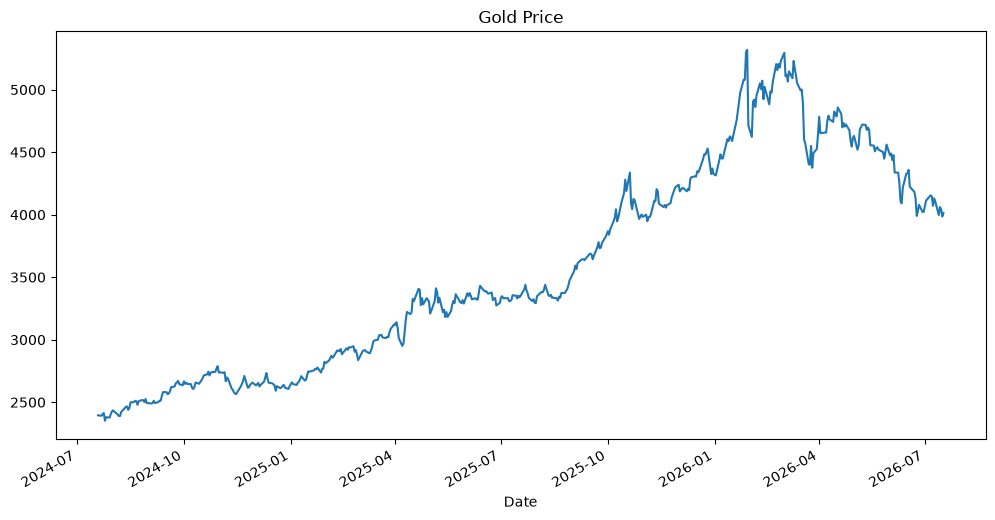

In [17]:
%pip install matplotlib
import matplotlib.pyplot as plt
data['Close'].plot(title = "Gold Price", figsize = (12,6))